In [1]:
# get abs of residuals from each condition and sum
# then compare to combined z-scores from #17

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.spatial import cKDTree

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
#pio.renderers.default = "iframe"

In [2]:
# figure save directory
save_dir = "../../img/sum_residuals"
os.makedirs(save_dir, exist_ok=True)

input_file = '../../results/barseq/combined_grouped-barcodes_241120.csv'
df = pd.read_csv(input_file)

In [3]:
# pivot to wide df
temp_df = (
    df.pivot(index=["pkr","site"], columns="k3", values="auc_mean")
      .dropna()
)


In [4]:
# --- helper: distance to curve ---
def distances_to_curve(x_curve, y_curve, x_pts, y_pts):
    """
    Uses KD-tree for fast nearest point on curve.
    """
    curve_pts = np.column_stack([x_curve, y_curve])
    tree = cKDTree(curve_pts)
    dists, _ = tree.query(np.column_stack([x_pts, y_pts]))
    return dists

def signed_distances_to_curve(x_curve, y_curve, x_pts, y_pts):
    """
    Returns signed shortest distance from each point to a curve.
    Positive = above curve
    Negative = below curve
    """

    curve_pts = np.column_stack([x_curve, y_curve])
    tree = cKDTree(curve_pts)

    pts = np.column_stack([x_pts, y_pts])

    dists, idx = tree.query(pts)

    signed = np.zeros_like(dists)

    for i, (p, j) in enumerate(zip(pts, idx)):

        # nearest curve point
        c = curve_pts[j]

        # get local tangent using neighbors
        if j == 0:
            t = curve_pts[1] - curve_pts[0]
        elif j == len(curve_pts) - 1:
            t = curve_pts[-1] - curve_pts[-2]
        else:
            t = curve_pts[j+1] - curve_pts[j-1]

        v = p - c

        # 2D cross product (scalar)
        cross = t[0]*v[1] - t[1]*v[0]

        sign = np.sign(cross)

        signed[i] = dists[i] * sign

    return signed

In [5]:
all_dists = []
store = {}
dist_df = pd.DataFrame(index=temp_df.index)

# ---- first pass: compute distances ----
cond_list = ['VACV K3','VARV C3','TPV K3','RCVZ vIF2α']
combo_pairs = list(combinations(cond_list, 2))
combo_pairs

for (cond_a,cond_b) in combo_pairs:

    combo_name = f"{cond_a} x {cond_b}"

    x = temp_df[cond_a].values
    y = temp_df[cond_b].values

    sm = lowess(y, x, frac=0.4, return_sorted=True)
    x_fit, y_fit = sm[:,0], sm[:,1]

    dists = distances_to_curve(x_fit, y_fit, x, y)

    store[combo_name] = (x, y, x_fit, y_fit, dists)
    all_dists.extend(dists)

    dist_df[combo_name] = dists


max_dist = np.max(all_dists)
min_dist = np.min(all_dists)

/var/folders/2_/3s1x89754mb6ctqh_1rrl4mc0000gn/T/ipykernel_2176/3786666916.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


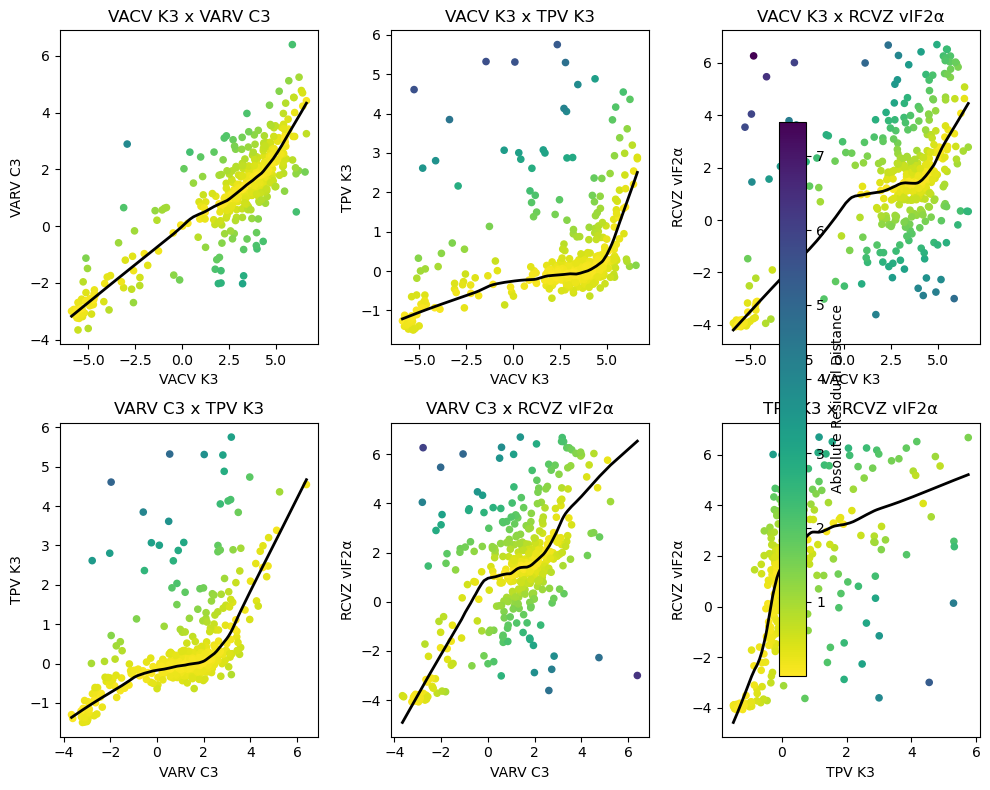

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(10,8), sharex=False, sharey=False)

axes = axes.flatten()

scatter_handle = None  # will store one scatter for colorbar

for i, (cond_a,cond_b) in enumerate(combo_pairs):

    ax = axes[i]

    combo_name = f"{cond_a} x {cond_b}"
    
    x, y, x_fit, y_fit, dists = store[combo_name]

    sc = ax.scatter(
        x, y,
        c=dists,
        cmap="viridis_r",
        vmin=min_dist,
        vmax=max_dist,
        s=20
    )

    ax.plot(x_fit, y_fit, color='black', lw=2)

    ax.set_xlabel(cond_a)
    ax.set_ylabel(cond_b)
    ax.set_title(combo_name)

    if scatter_handle is None:
        scatter_handle = sc   # save for shared colorbar


# ---- turn off last (bottom-right) panel ----
#axes[-1].axis("off")


# ---- single shared colorbar ----
cbar = fig.colorbar(
    scatter_handle,
    ax=axes,
    location="right",
    shrink=0.9,
    pad=0.02
)

cbar.set_label("Absolute Residual Distance")


plt.tight_layout()

plot_name = f'all-pairs-residuals_lowess.svg'
output_file = os.path.join(save_dir, plot_name)
#plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

plt.show()

In [7]:
dist_df['distance_sum'] = dist_df.sum(axis=1)
dist_df.reset_index(inplace=True)

dist_df.sort_values('distance_sum', inplace=True, ascending=False)
dist_df['distance_order'] = range(len(dist_df))

<Axes: xlabel='distance_order', ylabel='distance_sum'>

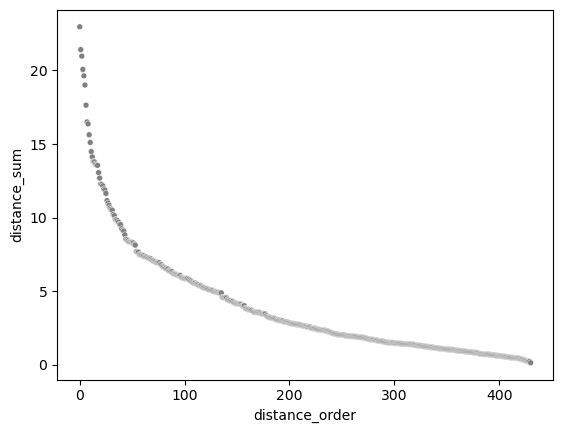

In [8]:
# Format Plot
fig, ax = plt.subplots()

sns.scatterplot(
    ax=ax,
    data=dist_df,
    y='distance_sum',
    x='distance_order',
    size=3,
    legend=False,
    alpha=1,
    #facecolor='none',
    color='gray'
    #edgecolor=dist_df['color'],
    #linewidth=temp_df['linewidth']
)

In [9]:
# interesting sites: 455,489,452,453,490
dist_df[dist_df['distance_sum'] > 10]['site'].value_counts()

site
489.0    5
455.0    5
453.0    3
452.0    3
488.0    3
382.0    3
490.0    3
454.0    2
485.0    2
495.0    1
492.0    1
487.0    1
275.0    1
482.0    1
Name: count, dtype: int64

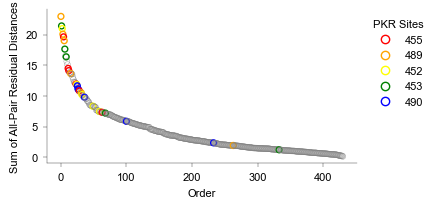

In [10]:
# interesting sites: 455,489,452,453,490
color_dict = {
    455:'red',
    489:'orange',
    452:'yellow',
    453:'green',
    490:'blue'
}

dist_df["color"] = dist_df["site"].map(color_dict).fillna("gray")
sites = list(color_dict.keys())
dist_df["size"] = np.where(
    dist_df["site"].isin(sites),
    1,
    .25
)

# Format Plot
width_in = 4
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = 1
marker_diameter = 3 # 1.75
big_markers = 1
small_markers = .25

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)

# figure size
fig, ax = plt.subplots(figsize=(width_in, height_in))

# Data
sns.scatterplot(
    ax=ax,
    data=dist_df,
    y='distance_sum',
    x='distance_order',
    size=marker_diameter,
    legend=False,
    alpha=alpha_val,
    facecolor='none',
    edgecolor=dist_df['color'],
    linewidth=dist_df['size']
)

# Axis Parameters

# Set y-axis range
#ax.set_ylim(-4,5)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)

# Set font properties for axis labels
ax.set_xlabel(f'Order', fontsize=font_size, fontname=font_name)
ax.set_ylabel(f'Sum of All-Pair Residual Distances', fontsize=font_size, fontname=font_name)

# Legend
handles_col1 = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='none',
        markeredgecolor=color_dict[pos],
        markeredgewidth=big_markers,
        label=str(pos)
    )
    for pos in [455,489,452,453,490]
]


# Add legend
leg1 = ax.legend(
    handles=handles_col1,
    title="PKR Sites",
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

plot_name = f'curve_all-pairs_abs-sum-residuals.svg'
save_dir = '../../img/sum_residuals'
output_file = os.path.join(save_dir, plot_name)
#plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

plt.show()

In [15]:
# now combine these residual distances with the combined z-scores across all 4 conditions from #17
df1 = dist_df.copy()
df2 = pd.read_csv('../../results/zscores/combined-zscores_vacv-varv-tpv-rcv.csv')

temp_df = pd.merge(df1, df2[['pkr', 'VACV K3 z-score','VARV C3 z-score','TPV K3 z-score','RCVZ vIF2α z-score','combined z-scores']])

In [17]:
temp_df.to_csv('../../results/zscores/z-scores_all-pairs-residual-distances.csv', index=False)

In [18]:
temp_df.columns.tolist()

['pkr',
 'site',
 'VACV K3 x VARV C3',
 'VACV K3 x TPV K3',
 'VACV K3 x RCVZ vIF2α',
 'VARV C3 x TPV K3',
 'VARV C3 x RCVZ vIF2α',
 'TPV K3 x RCVZ vIF2α',
 'distance_sum',
 'distance_order',
 'color',
 'size',
 'VACV K3 z-score',
 'VARV C3 z-score',
 'TPV K3 z-score',
 'RCVZ vIF2α z-score',
 'combined z-scores']

<Axes: xlabel='combined z-scores', ylabel='distance_sum'>

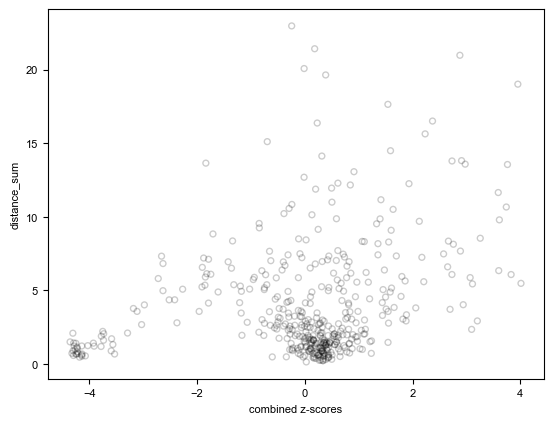

In [25]:
# Format Plot
fig, ax = plt.subplots()

sns.scatterplot(
    ax=ax,
    data=temp_df,
    x='combined z-scores',
    y='distance_sum',
    size=3,
    legend=False,
    alpha=.2,
    facecolor='none',
    color='gray',
    edgecolor='black',
    linewidth=1,

)

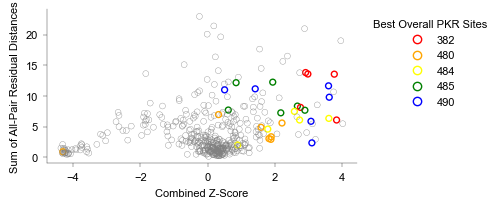

In [26]:
# interesting sites: 
# best overall sites: 382,480,484,485,490    
# most eratic sites: 455,489,452,453,490
color_dict = {
    382:'red',
    480:'orange',
    484:'yellow',
    485:'green',
    490:'blue'
}

temp_df["color"] = temp_df["site"].map(color_dict).fillna("gray")
sites = list(color_dict.keys())
temp_df["size"] = np.where(
    temp_df["site"].isin(sites),
    1,
    .25
)

# Format Plot
width_in = 4
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = 1
marker_diameter = 3 # 1.75
big_markers = 1
small_markers = .25

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)

# figure size
fig, ax = plt.subplots(figsize=(width_in, height_in))

# Data
sns.scatterplot(
    ax=ax,
    data=temp_df,
    x = 'combined z-scores',
    y = 'distance_sum',
    size=marker_diameter,
    legend=False,
    alpha=alpha_val,
    facecolor='none',
    edgecolor=temp_df['color'],
    linewidth=temp_df['size']
)

# Axis Parameters

# Set y-axis range
#ax.set_ylim(-4,5)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)

# Set font properties for axis labels
ax.set_xlabel(f'Combined Z-Score', fontsize=font_size, fontname=font_name)
ax.set_ylabel(f'Sum of All-Pair Residual Distances', fontsize=font_size, fontname=font_name)

# Legend
handles_col1 = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='none',
        markeredgecolor=color_dict[pos],
        markeredgewidth=big_markers,
        label=str(pos)
    )
    for pos in [382,480,484,485,490 ]
]

# Add legend
leg1 = ax.legend(
    handles=handles_col1,
    title="Best Overall PKR Sites",
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

plot_name = f'scatter_combined-zscores_all-pairs-residuals.svg'
save_dir = '../../img/residuals'
output_file = os.path.join(save_dir, plot_name)
plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

plt.show()

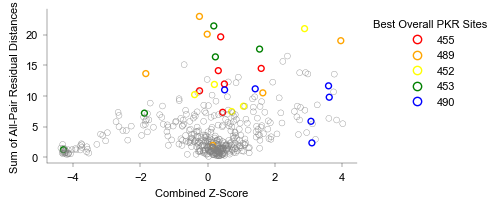

In [27]:
# now collor the erratic sites
# most eratic sites: 455,489,452,453,490
color_dict = {
    455:'red',
    489:'orange',
    452:'yellow',
    453:'green',
    490:'blue'
}

temp_df["color"] = temp_df["site"].map(color_dict).fillna("gray")
sites = list(color_dict.keys())
temp_df["size"] = np.where(
    temp_df["site"].isin(sites),
    1,
    .25
)

# Format Plot
width_in = 4
height_in = 2
font_size = 8
font_name = 'Arial'
stroke = .25
tick_len = 3
alpha_val = 1
marker_diameter = 3 # 1.75
big_markers = 1
small_markers = .25

font = {'family': font_name, 'size': font_size}
plt.rc('font', **font)
plt.rc('lines', linewidth=stroke)

# figure size
fig, ax = plt.subplots(figsize=(width_in, height_in))

# Data
sns.scatterplot(
    ax=ax,
    data=temp_df,
    x = 'combined z-scores',
    y = 'distance_sum',
    size=marker_diameter,
    legend=False,
    alpha=alpha_val,
    facecolor='none',
    edgecolor=temp_df['color'],
    linewidth=temp_df['size']
)

# Axis Parameters

# Set y-axis range
#ax.set_ylim(-4,5)

# Set tick parameters
ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)

# Set font properties for axis labels
ax.set_xlabel(f'Combined Z-Score', fontsize=font_size, fontname=font_name)
ax.set_ylabel(f'Sum of All-Pair Residual Distances', fontsize=font_size, fontname=font_name)

# Legend
handles_col1 = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='none',
        markeredgecolor=color_dict[pos],
        markeredgewidth=big_markers,
        label=str(pos)
    )
    for pos in [455,489,452,453,490]
]

# Add legend
leg1 = ax.legend(
    handles=handles_col1,
    title="Best Overall PKR Sites",
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(stroke)
ax.spines['bottom'].set_linewidth(stroke)

plot_name = f'scatter_combined-zscores_all-pairs-residuals_erratic-sites.svg'
save_dir = '../../img/residuals'
output_file = os.path.join(save_dir, plot_name)
plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

plt.show()